# Module M1.1 — Raw Data Loading & Deduplication

**Project:** Explainable and Bias-Aware ML for Phishing Website Detection  
**Dataset:** PhiUSIIL Phishing URL Dataset  
**Roadmap ref:** Phase 1 → Module M1.1  

### Objectives
1. Load the raw CSV from `data/raw/`  
2. Validate shape, columns, missing values, and label values  
3. Detect and remove duplicate URLs  
4. Confirm class distribution before and after deduplication  
5. Save `data/processed/clean_df.csv`  
6. Generate `outputs/reports/m1_1_data_audit_report.html`  


## 0. Environment Setup

In [1]:
import sys
import os
from pathlib import Path

# ── Ensure project root is on sys.path ───────────────────────────────
PROJECT_ROOT = Path().resolve().parent  # notebooks/ → project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root : {PROJECT_ROOT}')
print(f'Python       : {sys.version}')


Project root : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection
Python       : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import seaborn               as sns

from src.utils.logger  import get_logger
from src.data.loader   import run_full_validation
from src.data.cleaner  import (
    detect_duplicates,
    remove_duplicates,
    validate_class_distribution,
    save_clean_df,
    generate_audit_report,
    run_cleaning_pipeline,
)

logger = get_logger('notebook.01_data_audit')

# Notebook-wide plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Imports OK')


Imports OK


## 1. Path Configuration

In [3]:
RAW_CSV      = PROJECT_ROOT / 'data' / 'raw' / 'PhiUSIIL_Phishing_URL_Dataset.csv'
CLEAN_CSV    = PROJECT_ROOT / 'data' / 'processed' / 'clean_df.csv'
REPORT_DIR   = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_EDA    = PROJECT_ROOT / 'outputs' / 'plots' / 'eda'

for p in [RAW_CSV, CLEAN_CSV.parent, REPORT_DIR, PLOTS_EDA]:
    if p.suffix:          # it is a file
        assert p.exists(), f'Dataset not found: {p}'
    else:                 # it is a directory
        p.mkdir(parents=True, exist_ok=True)

print(f'Raw dataset  : {RAW_CSV}')
print(f'Output CSV   : {CLEAN_CSV}')
print(f'Report dir   : {REPORT_DIR}')


Raw dataset  : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\data\raw\PhiUSIIL_Phishing_URL_Dataset.csv
Output CSV   : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\data\processed\clean_df.csv
Report dir   : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports


## 2. Load Dataset & Run Full Validation

In [4]:
df_raw, validation_report = run_full_validation(RAW_CSV)
print(f'\nDataFrame shape: {df_raw.shape}')


2026-06-17 16:45:22 | INFO     | src.data.loader                          | ============================================================
2026-06-17 16:45:22 | INFO     | src.data.loader                          | MODULE M1.1  —  DATASET VALIDATION
2026-06-17 16:45:22 | INFO     | src.data.loader                          | ============================================================
2026-06-17 16:45:22 | INFO     | src.data.loader                          | Loading dataset  : PhiUSIIL_Phishing_URL_Dataset.csv
2026-06-17 16:45:22 | INFO     | src.data.loader                          | File size        : 56.85 MB
2026-06-17 16:45:28 | INFO     | src.data.loader                          | Loaded           : 235,795 rows × 56 columns
2026-06-17 16:45:28 | INFO     | src.data.loader                          | Shape check      : 235,795 rows × 56 columns
2026-06-17 16:45:28 | INFO     | src.data.loader                          | Expected         : 235,795 rows × 56 columns
2026-06-17 16:45:28


DataFrame shape: (235795, 56)


In [5]:
# Print the validation report dictionary
import pprint
pprint.pprint(validation_report)


{'class_distribution': {'class_ratio': np.float64(0.748572),
                        'legitimate_count': 134850,
                        'legitimate_pct': np.float64(57.1895),
                        'phishing_count': 100945,
                        'phishing_pct': np.float64(42.8105),
                        'total': 235795},
 'cols': 56,
 'columns_valid': True,
 'columns_with_missing': [],
 'dtype_counts': {'float64': 10, 'int64': 41, 'str': 5},
 'missing_columns': [],
 'rows': 235795,
 'total_missing': 0}


## 3. Missing Value Analysis

In [6]:
missing = df_raw.isnull().sum()
total_missing = missing.sum()

print(f'Total missing values : {total_missing}')
if total_missing == 0:
    print('Dataset is complete — no imputation required.')
else:
    print(missing[missing > 0].sort_values(ascending=False))


Total missing values : 0
Dataset is complete — no imputation required.


## 4. Data Types Summary

In [7]:
dtype_df = pd.DataFrame({
    'dtype' : df_raw.dtypes.astype(str),
    'nunique': df_raw.nunique(),
    'sample' : [str(df_raw[c].iloc[0])[:40] for c in df_raw.columns],
})
print(dtype_df.to_string())


                              dtype  nunique                                    sample
FILENAME                        str   235795                                521848.txt
URL                             str   235370          https://www.southbankmosaics.com
URLLength                     int64      482                                        31
Domain                          str   220086                  www.southbankmosaics.com
DomainLength                  int64      101                                        24
IsDomainIP                    int64        2                                         0
TLD                             str      695                                       com
URLSimilarityIndex          float64    36360                                     100.0
CharContinuationRate        float64      898                                       1.0
TLDLegitimateProb           float64      465                                 0.5229071
URLCharProb                 float64   22742

## 5. Duplicate URL Detection

In [8]:
duplicate_rows, dup_count = detect_duplicates(df_raw)
print(f'Duplicate rows: {dup_count:,}')


2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Detecting duplicates on column: 'URL'
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Total rows          : 235,795
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Unique URLs         : 235,370
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Duplicate rows found: 425
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Class distribution inside duplicates:
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         |   label=0 Phishing   : 425
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         |   label=1 Legitimate : 0


Duplicate rows: 425


In [9]:
if dup_count > 0:
    print('Sample duplicate rows (showing first 5):')
    display(duplicate_rows[['URL', 'label']].head())
    print(f'\nClass breakdown in duplicates:')
    print(duplicate_rows['label'].value_counts())


Sample duplicate rows (showing first 5):


,URL,label
17648,https://request-review-599826.firebaseapp.com/,0
22438,https://dexstatuschain.com/,0
23107,https://project5-d6656.firebaseapp.com/,0
28566,https://att-verification-c80fbf.webflow.io/,0
32321,https://arekar.in/vystarcureviewpendingpayment/,0



Class breakdown in duplicates:
label
0    425
Name: count, dtype: int64


## 6. Remove Duplicates

In [10]:
df_clean = remove_duplicates(df_raw)
print(f'Before : {len(df_raw):,} rows')
print(f'After  : {len(df_clean):,} rows')
print(f'Removed: {len(df_raw) - len(df_clean):,} rows')


2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Removing duplicates (keep='first') …
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Rows removed        : 425
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Rows retained       : 235,370


Before : 235,795 rows
After  : 235,370 rows
Removed: 425 rows


## 7. Class Distribution — Before vs After Deduplication

In [11]:
pre_dist  = validate_class_distribution(df_raw,   stage='pre-dedup')
post_dist = validate_class_distribution(df_clean, stage='post-dedup')


2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Class distribution [pre-dedup]:
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         |   Total samples        : 235,795
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         |   label=0 Phishing     : 100,945 (42.81%)
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         |   label=1 Legitimate   : 134,850    (57.19%)
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         |   Imbalance ratio (0/1): 0.7486
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         | Class distribution [post-dedup]:
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         |   Total samples        : 235,370
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         |   label=0 Phishing     : 100,520 (42.71%)
2026-06-17 16:45:30 | INFO     | src.data.cleaner                         |   label=1 Legitimate   :

findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 500, now using 400.


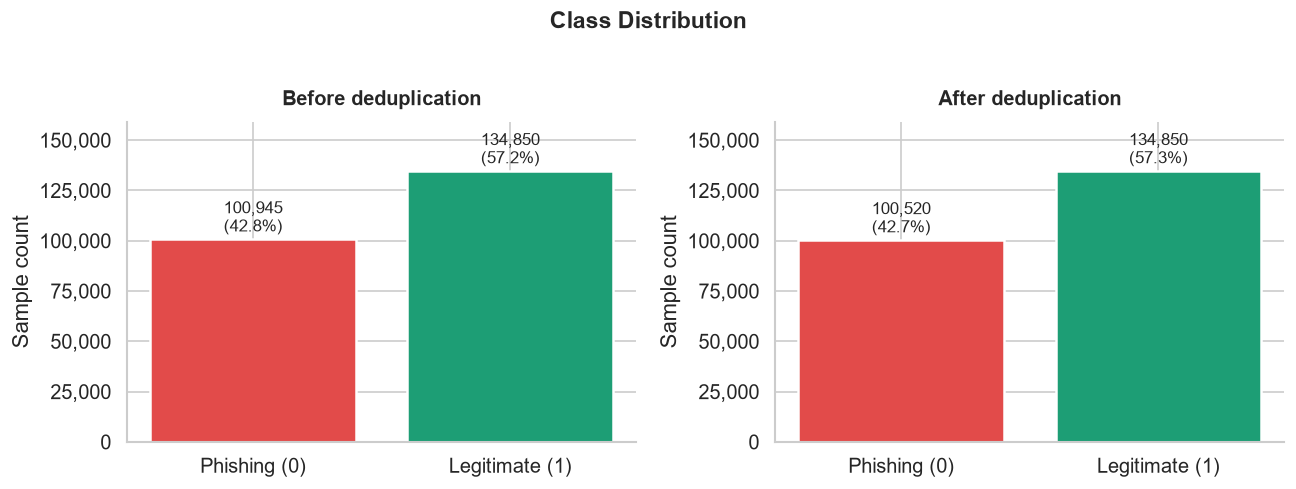

Saved → outputs/plots/eda/class_distribution.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, dist, title in zip(
    axes,
    [pre_dist, post_dist],
    ['Before deduplication', 'After deduplication'],
):
    classes = ['Phishing (0)', 'Legitimate (1)']
    counts  = [dist['phishing_count'], dist['legitimate_count']]
    colors  = ['#E24B4A', '#1D9E75']
    bars = ax.bar(classes, counts, color=colors, edgecolor='white', linewidth=1.5)

    for bar, cnt, pct in zip(
        bars, counts,
        [dist['phishing_pct'], dist['legitimate_pct']],
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            f'{cnt:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='500',
        )

    ax.set_title(title, fontsize=12, fontweight='600', pad=10)
    ax.set_ylabel('Sample count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_ylim(0, max(counts) * 1.18)
    sns.despine(ax=ax)

fig.suptitle('Class Distribution', fontsize=14, fontweight='700', y=1.02)
fig.tight_layout()
plt.savefig(PLOTS_EDA / 'class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → outputs/plots/eda/class_distribution.png')


findfont: Failed to find font weight 600, now using 700.


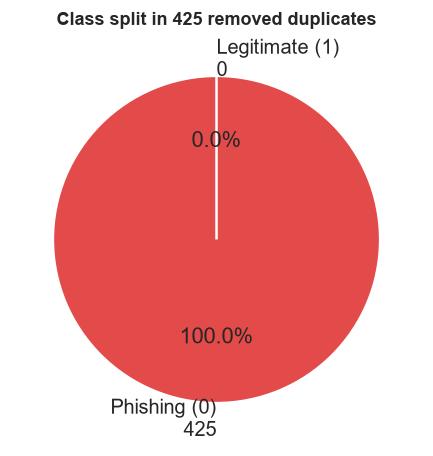

Saved → outputs/plots/eda/duplicates_class_split.png


In [13]:
if dup_count > 0:
    fig, ax = plt.subplots(figsize=(5, 4))
    dup_vc  = duplicate_rows['label'].value_counts().sort_index()
    labels  = [f'Phishing (0)\n{dup_vc.get(0,0)}',
               f'Legitimate (1)\n{dup_vc.get(1,0)}']
    ax.pie(
        [dup_vc.get(0,0), dup_vc.get(1,0)],
        labels=labels, colors=['#E24B4A','#1D9E75'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5},
    )
    ax.set_title(f'Class split in {dup_count} removed duplicates',
                 fontsize=11, fontweight='600')
    plt.tight_layout()
    plt.savefig(PLOTS_EDA / 'duplicates_class_split.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved → outputs/plots/eda/duplicates_class_split.png')


## 8. DataFrame Info (clean)

In [14]:
print(f'Shape: {df_clean.shape}')
print('\nDtype summary:')
print(df_clean.dtypes.value_counts())
print('\nFirst 3 rows:')
display(df_clean.head(3))


Shape: (235370, 56)

Dtype summary:
int64      41
float64    10
str         5
Name: count, dtype: int64

First 3 rows:


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1


## 9. Numeric Feature Descriptive Statistics

In [15]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'label']

stats_df = df_clean[numeric_cols].describe().T
stats_df['skew']  = df_clean[numeric_cols].skew()
stats_df['kurtosis'] = df_clean[numeric_cols].kurt()

# Highlight highly skewed features
highly_skewed = stats_df[stats_df['skew'].abs() > 5]['skew'].sort_values(ascending=False)
print(f'Features with |skew| > 5 ({len(highly_skewed)} total):')
print(highly_skewed.to_string())


Features with |skew| > 5 (22 total):
NoOfCSS                       463.992297
NoOfObfuscatedChar            204.506366
NoOfJS                        140.375265
NoOfEqualsInURL               114.887278
NoOfEmptyRef                  106.738379
NoOfAmpersandInURL            106.627680
NoOfiFrame                     97.607158
NoOfDegitsInURL                94.907962
NoOfPopup                      84.879864
NoOfExternalRef                65.855061
NoOfSelfRef                    60.346935
NoOfLettersInURL               58.452964
URLLength                      53.346618
LineOfCode                     53.036533
LargestLineLength              47.851201
NoOfOtherSpecialCharsInURL     47.515701
ObfuscationRatio               40.140604
NoOfImage                      28.210672
HasObfuscation                 22.007197
IsDomainIP                     19.159489
NoOfQMarkInURL                  8.159639
Crypto                          6.292428


## 10. Save clean_df.csv

In [16]:
save_clean_df(df_clean, CLEAN_CSV)
print(f'Saved: {CLEAN_CSV}')
print(f'Size : {CLEAN_CSV.stat().st_size / 1e6:.2f} MB')


2026-06-17 16:45:34 | INFO     | src.data.cleaner                         | Saving clean DataFrame → C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\data\processed\clean_df.csv
2026-06-17 16:45:46 | INFO     | src.data.cleaner                         | Saved             : 235,370 rows × 56 cols  (59.03 MB)


Saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\data\processed\clean_df.csv
Size : 59.03 MB


## 11. Generate HTML Audit Report

In [17]:
report_path = generate_audit_report(
    df_original      = df_raw,
    df_clean         = df_clean,
    duplicate_rows   = duplicate_rows,
    validation_report= validation_report,
    output_dir       = REPORT_DIR,
)
print(f'Report saved: {report_path}')


2026-06-17 16:45:46 | INFO     | src.data.cleaner                         | Audit report saved : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\m1_1_data_audit_report.html


Report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\m1_1_data_audit_report.html


## 12. Full Pipeline (Single-Call Re-run)

The cell below demonstrates running everything through the pipeline
orchestrator in a single call. Useful for CI/testing.


In [18]:
# Uncomment to re-run the entire pipeline from scratch
# df_clean_v2, cleaning_report = run_cleaning_pipeline(
#     df_raw           = df_raw,
#     output_path      = CLEAN_CSV,
#     report_dir       = REPORT_DIR,
#     validation_report= validation_report,
# )
# print(cleaning_report)


## 13. M1.1 Summary

In [19]:
summary = {
    'raw_rows'             : len(df_raw),
    'duplicate_rows_removed': dup_count,
    'clean_rows'           : len(df_clean),
    'total_columns'        : df_clean.shape[1],
    'missing_values'       : int(df_clean.isnull().sum().sum()),
    'phishing_count'       : int((df_clean['label'] == 0).sum()),
    'legitimate_count'     : int((df_clean['label'] == 1).sum()),
    'phishing_pct'         : round((df_clean['label'] == 0).mean() * 100, 2),
    'legitimate_pct'       : round((df_clean['label'] == 1).mean() * 100, 2),
    'output_csv'           : str(CLEAN_CSV),
    'audit_report'         : report_path,
}

print('=' * 55)
print('MODULE M1.1 COMPLETE')
print('=' * 55)
for k, v in summary.items():
    print(f'  {k:<28}: {v}')
print('=' * 55)
print('Next step → M1.2: Column Removal & Feature Set Finalization')


MODULE M1.1 COMPLETE
  raw_rows                    : 235795
  duplicate_rows_removed      : 425
  clean_rows                  : 235370
  total_columns               : 56
  missing_values              : 0
  phishing_count              : 100520
  legitimate_count            : 134850
  phishing_pct                : 42.71
  legitimate_pct              : 57.29
  output_csv                  : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\data\processed\clean_df.csv
  audit_report                : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\m1_1_data_audit_report.html
Next step → M1.2: Column Removal & Feature Set Finalization
